# Memory · strategy comparison

FWI backward passes need access to the full forward wavefield to compute
the imaging condition. The three common ways to make that tractable are:

- **Full wavefield (no savings):** store every timestep; fastest but most
  memory-hungry.
- **Boundary saving:** during forward, save a thin
  stencil-width strip along each side of the **physical interior**
  (the inward-facing halo at the interior↔PML interface) plus the
  last two interior wavefield snapshots; during backward, replay the
  forward by reverse-time propagation seeded from those saved
  values. Cheap memory, ~2× more compute.
- **Checkpointing:** save snapshots at intermediate timesteps; replay
  forward from the nearest checkpoint when backward needs a missing
  timestep. Memory–compute trade-off you can dial.

This notebook runs **one forward + backward step** of a small acoustic
FWI problem under five memory strategies and reports peak GPU memory +
wallclock. The whole point is to show **how to express each strategy via
the public ``CUDAOptions`` / top-level kwargs API** — copy-paste the
lines from the loop below into your own scripts.


## 1. Setup — one shot on 25 m Marmousi

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh, dt, nt = MARMOUSI_DH * 2, 0.002, 2000   # 25 m, 4 s
freq, delay = 5.0, 0.20

vp_true_np = load_marmousi('true')[::2, ::2].copy()
vp_init_np = load_marmousi('smooth')[::2, ::2].copy()
shape = vp_true_np.shape
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, ' shape:', shape, ' record:', f'{nt*dt:.1f} s')

nshots, nrec = 1, 100   # single shot keeps the no-savings baseline within memory
src_x = np.array([shape[1] // 2], dtype=np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
sources   = np.stack([src_x, np.full(nshots, 2, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, 4, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)
vp_true_t = torch.tensor(vp_true_np, device=device)


device: cuda  shape: (141, 681)  record: 4.0 s


## 2. Generate the observed data once

The observed shot stays fixed across strategies; we only vary how the
**solver** stores its forward state for the backward pass.


In [2]:
with torch.no_grad():
    eq = Acoustic(device=device)
    solver_obs = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt)   # impl='auto' → 'c'
    observed = solver_obs(wavelet, sources, receivers, models=[vp_true_t]).detach()
print('observed:', tuple(observed.shape))
del solver_obs
torch.cuda.empty_cache()


observed: (1, 2000, 100, 1)


### Aside · which sources and receivers does this equation accept?

`Acoustic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [3]:
print('models (input order matters!):')
for spec in eq.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq.default_source_fields, '/', eq.default_receiver_fields)
print('receivers :')
for spec in eq.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


## 3. The strategies

**How parameters flow into PropTorch.** Memory configuration
lives in one of two places depending on the backend:

- ``impl='eager'`` — eager memory knobs (``use_ckpt``,
  ``ckpt_chunks``) are plain top-level kwargs.
- ``impl='c'`` — structured ``memory=`` block:
  ``memory = {'strategy': 'boundary' | 'ckpt', '<strategy>': {...}}``.

We use **dict literals** below so the hierarchy is visible in the
indentation. Each level maps 1-to-1 to a dataclass — useful if
you want IDE autocomplete in your own scripts:

```
PropTorch
 ├── eager_options : EagerOptions          # eager-only (compile flags)
 └── cuda_options  : CUDAOptions           # c-only memory block
      └── memory   : MemoryOptions         # pick one strategy:
           ├── boundary : BoundaryOptions  # storage / pinning / interval
           └── ckpt     : CkptOptions      # chunk / recursive
```

Equivalent dataclass form for the second-to-last strategy:

```python
from sweep.propagator.options import (
    CUDAOptions, MemoryOptions, BoundaryOptions,
)
PropTorch(..., impl='c',
          cuda_options=CUDAOptions(memory=MemoryOptions(
              strategy='boundary',
              boundary=BoundaryOptions(storage='cpu',
                                       pinned_memory=True,
                                       transfer_interval=4))))
```


In [4]:
strategies = []

# --- eager backend (top-level kwargs) --------------------------------
strategies.append((
    'eager · full',
    dict(impl='eager', use_ckpt=False),
))
strategies.append((
    'eager · chunk-ckpt',
    dict(impl='eager', use_ckpt=True, ckpt_chunks=100),
))

# --- compiled c backend ---------------------------------------------
# 'c · full' — no memory= block, just disable ckpt at the top level.
strategies.append((
    'c · full',
    dict(impl='c', use_ckpt=False),
))

# memory = MemoryOptions(strategy='boundary', boundary=BoundaryOptions(...))
# Boundary saving stores a stencil-wide halo strip along each side of
# the physical interior (NOT the PML region itself) plus the last two
# interior snapshots; the interior wavefield is replayed by reverse-
# time propagation seeded from those values during backward.
strategies.append((
    'c · boundary (GPU)',
    dict(impl='c',
         memory={'strategy': 'boundary',
                 'boundary': {'storage': 'gpu'}}),
))
strategies.append((
    'c · boundary (CPU pinned)',
    dict(impl='c',
         memory={'strategy': 'boundary',
                 'boundary': {'storage': 'cpu',
                              'pinned_memory': True}}),
))
strategies.append((
    'c · boundary (CPU, interval=4)',
    dict(impl='c',
         memory={'strategy': 'boundary',
                 'boundary': {'storage': 'cpu',
                              'pinned_memory': True,
                              'transfer_interval': 4}}),
))

# memory = MemoryOptions(strategy='ckpt', ckpt=CkptOptions(...))
# 'chunk' = save every N steps; 'recursive' = K snapshots fractal schedule.
strategies.append((
    'c · chunk-ckpt',
    dict(impl='c',
         memory={'strategy': 'ckpt',
                 'ckpt': {'mode': 'chunk', 'chunks': 100}}),
))
strategies.append((
    'c · recursive-ckpt',
    dict(impl='c',
         memory={'strategy': 'ckpt',
                 'ckpt': {'mode': 'recursive', 'count': 8}}),
))

for label, kw in strategies:
    print(f'{label:34s} → {kw}')


eager · full                       → {'impl': 'eager', 'use_ckpt': False}
eager · chunk-ckpt                 → {'impl': 'eager', 'use_ckpt': True, 'ckpt_chunks': 100}
c · full                           → {'impl': 'c', 'use_ckpt': False}
c · boundary (GPU)                 → {'impl': 'c', 'memory': {'strategy': 'boundary', 'boundary': {'storage': 'gpu'}}}
c · boundary (CPU pinned)          → {'impl': 'c', 'memory': {'strategy': 'boundary', 'boundary': {'storage': 'cpu', 'pinned_memory': True}}}
c · boundary (CPU, interval=4)     → {'impl': 'c', 'memory': {'strategy': 'boundary', 'boundary': {'storage': 'cpu', 'pinned_memory': True, 'transfer_interval': 4}}}
c · chunk-ckpt                     → {'impl': 'c', 'memory': {'strategy': 'ckpt', 'ckpt': {'mode': 'chunk', 'chunks': 100}}}
c · recursive-ckpt                 → {'impl': 'c', 'memory': {'strategy': 'ckpt', 'ckpt': {'mode': 'recursive', 'count': 8}}}


## 4. Measure peak memory + wallclock for forward + backward

One forward + one MSE gradient against the smooth start. Peak GPU
memory captured between ``torch.cuda.reset_peak_memory_stats()`` and the
``backward()``.


In [5]:
def measure(strategy_label, kwargs):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    eq = Acoustic(device=device)
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt, **kwargs)
    vp_p = torch.nn.Parameter(torch.tensor(vp_init_np, device=device))
    torch.cuda.synchronize(); t0 = time.time()
    pred = solver(wavelet, sources, receivers, models=[vp_p])
    loss = (pred - observed).pow(2).mean()
    loss.backward()
    torch.cuda.synchronize()
    dt_s = time.time() - t0
    peak = torch.cuda.max_memory_allocated() / 2**30
    grad_l2 = vp_p.grad.detach().pow(2).mean().sqrt().item()
    del solver, vp_p, pred, loss
    torch.cuda.empty_cache()
    return dict(label=strategy_label, time_s=dt_s, peak_gb=peak, grad_l2=grad_l2)

results = []
for label, kw in strategies:
    r = measure(label, kw)
    results.append(r)
    print(f"{r['label']:34s} peak={r['peak_gb']:6.2f} GB  fwd+bwd={r['time_s']:5.2f}s  ||grad||₂={r['grad_l2']:.3e}")


eager · full                       peak=  5.75 GB  fwd+bwd= 5.94s  ||grad||₂=3.097e-07


eager · chunk-ckpt                 peak=  0.39 GB  fwd+bwd= 5.21s  ||grad||₂=3.097e-07


c · full                           peak=  1.45 GB  fwd+bwd= 0.20s  ||grad||₂=1.365e-07
c · boundary (GPU)                 peak=  0.06 GB  fwd+bwd= 0.09s  ||grad||₂=1.370e-07


c · boundary (CPU pinned)          peak=  0.02 GB  fwd+bwd= 0.20s  ||grad||₂=1.370e-07
c · boundary (CPU, interval=4)     peak=  0.02 GB  fwd+bwd= 0.13s  ||grad||₂=1.370e-07


c · chunk-ckpt                     peak=  0.18 GB  fwd+bwd= 0.11s  ||grad||₂=1.365e-07


c · recursive-ckpt                 peak=  0.09 GB  fwd+bwd= 0.24s  ||grad||₂=1.365e-07


## 5. Visual summary

Same gradient magnitude across all strategies (a quick correctness
check) but very different peak memory and runtime. Pick a strategy
based on your GPU and how much extra compute you can afford.


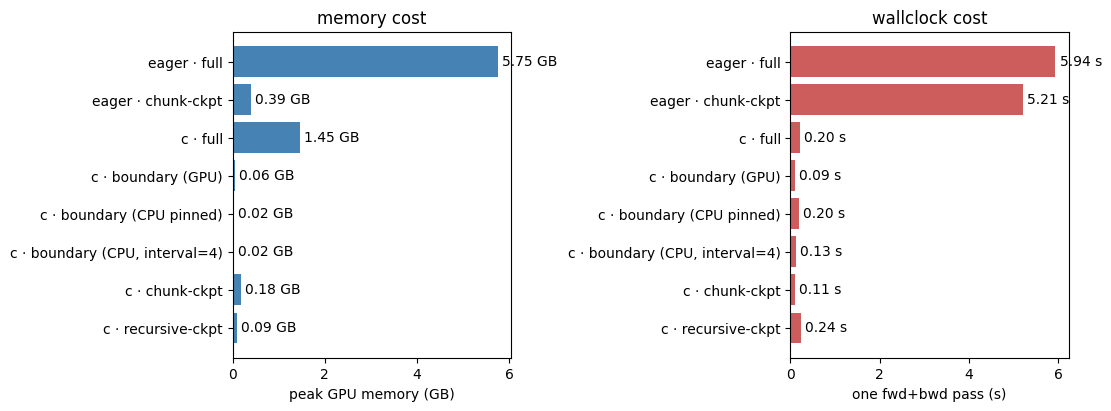

In [6]:
labels  = [r['label'] for r in results]
peaks   = [r['peak_gb'] for r in results]
times   = [r['time_s'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
bars0 = axes[0].barh(labels, peaks, color='steelblue')
axes[0].set_xlabel('peak GPU memory (GB)')
axes[0].set_title('memory cost')
axes[0].bar_label(bars0, fmt='%.2f GB', padding=3)
axes[0].invert_yaxis()

bars1 = axes[1].barh(labels, times, color='indianred')
axes[1].set_xlabel('one fwd+bwd pass (s)')
axes[1].set_title('wallclock cost')
axes[1].bar_label(bars1, fmt='%.2f s', padding=3)
axes[1].invert_yaxis()
plt.show()


---

<p><strong>Download this notebook</strong> &mdash; <a href="07_memory_strategies.ipynb" download><code>07_memory_strategies.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/07_memory_strategies.ipynb">view on GitHub</a></p>
